# **1 Spambase classification with Random Forest**

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification

1. Let’s start by loading the dataset :

In [51]:
dataspam = np.loadtxt("spambase.data", delimiter=",")
features_name = np.genfromtxt("spambase_variables.csv", delimiter=",", dtype="str")

In [52]:
print(dataspam.shape)

(4601, 58)


2. Build the matrix X and the vector y from the loaded data. Is the problem balanced ?

In [53]:
X = dataspam[:, :-1]
y = dataspam[:, -1]


In [54]:
unique, counts = np.unique(y, return_counts=True)
print("Class proportions:", counts / len(y))

Class proportions: [0.60595523 0.39404477]


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The dataset is not perfectly balanced, but I it is close.
  </p>
</div>

3. Split the dataset into a training and a test set, with 80% of the instances in the training set

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training:", X_train.shape[0])
print("Test:", X_test.shape[0])


Training: 3680
Test: 921


In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    I applied a normalization to improve the knn's performance.
  </p>
</div>

4. Train a decision tree and evaluate the performance on the test set.

In [57]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

proba = clf.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, proba)
print("\nROC-AUC:", roc_auc)

Accuracy: 0.9109663409337676

Confusion Matrix:
[[515  43]
 [ 39 324]]

ROC-AUC: 0.9077505257857165


5. Train several random forest classifiers with 10, 20, 50 and 100 trees and evaluate the performance on the test set.

In [60]:
n_trees_list = [10, 15, 20, 25, 50, 75, 100, 250, 500, 1000]

accuracies = []
rocs = []

for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n,random_state=42)

    rf.fit(X_train_scaled, y_train)

    y_pred = rf.predict(X_test_scaled)
    y_proba = rf.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    rocs.append(roc_auc_score(y_test, proba))


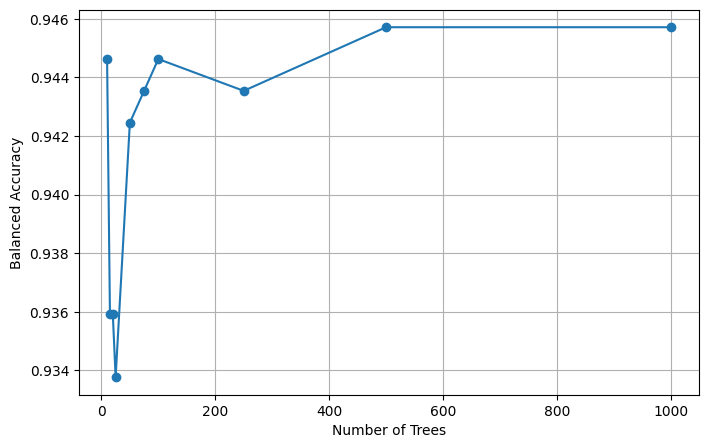

In [ ]:
# plot
plt.figure(figsize=(8, 5))

plt.plot(n_trees_list, accuracies, marker='o', label='Accuracy')

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

6. Train a K-Nearest Neighbors classifier for comparison purposes and evaluate the performance on the test set.

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)


Accuracy: 0.9077090119435396
ROC-AUC: 0.9505638002705451


7. Give your analysis of the results.

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The dataset is close to balance with a 60%/40% distribuition, which allows us to use accuracy instead of balanced accuaracy.
  </p>
  <p>
    We can observe that both the single tree classifier and the Knn can obtain a good result, but they are outperformed by the random forest approach. All the two simple models were inplemented with the standard hyperparameters, so a search could increase the accuracy.
  </p>
  <p>
    Comparing the number of classifiers of the random forest, the graph shows an unstable curve for lower numbers of classifiers, but always a smaller accuracy than higher numbers of classifiers. The accuracy also seems to converge for higher values, without reaching overfitting. This shows empirically that the RF model is safe from overfitting.
  </p>
</div>

# **2 Tuning the max_features hyperparameter**

1. Load the dataset and analyse the nature of this data. In particular, what do the features of
this dataset correspond to ? Intuitively, would you say that the features of this dataset are
mostly relevant ?

In [41]:
digits = load_digits()
print(digits.data.shape)

(1797, 64)


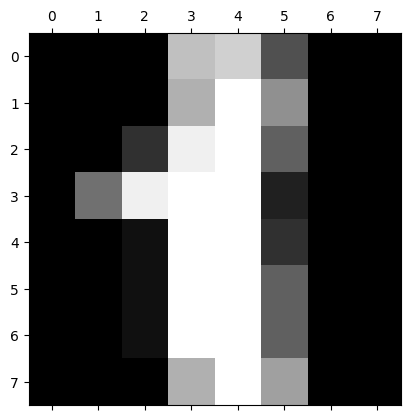

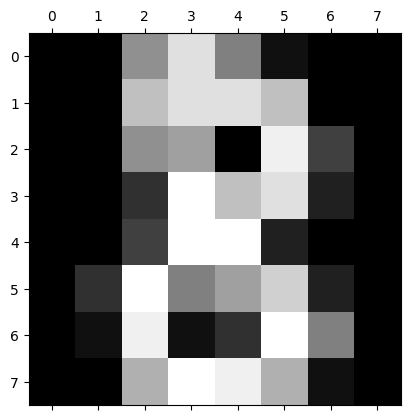

In [42]:
# plt.figure(figsize=(3, 3))
# plt.subplot(1,2,1)
plt.matshow(digits.images[1], cmap="gray")
# plt.subplot(1,2,2)
plt.matshow(digits.images[8], cmap="gray")
# plt.show()


2. Train several Random Forest classifiers with different values of max_features and compare their performance. For each candidate value, measure the average performance over several replications, along with the standard deviation.

In [43]:
X = digits.data[:, :-1]
y = digits.data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training:", X_train.shape[0])
print("Test:", X_test.shape[0])


Training: 1437
Test: 360


In [50]:
max_features_list = [1, 3, 5, 8, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 64]

accuracies = []
std = []

for n in max_features_list:
    rf = RandomForestClassifier(n_estimators=200,max_features=n)

    scores = cross_val_score(rf, X, y, cv=5)

    accuracies.append(scores.mean())
    std.append(scores.std())

rf.fit(X_train, y_train)
importances = rf.feature_importances_
std_feat = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

3. Present the results obtained on a graph and give your analysis of this graph, as well as your
conclusions ?

/tmp/ipython-input-4199791032.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


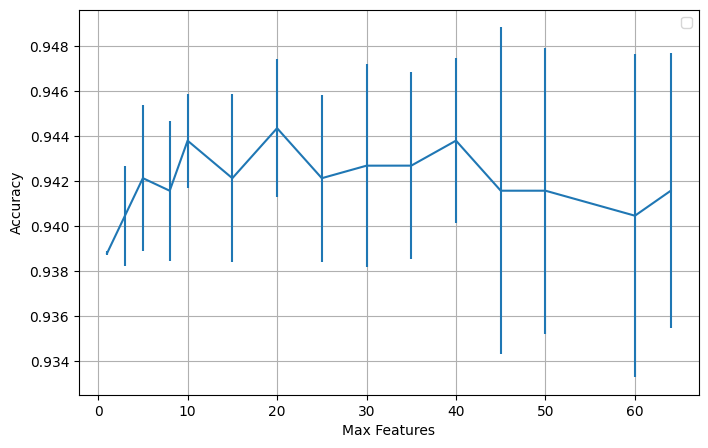

In [48]:
# plot
plt.figure(figsize=(8, 5))

# plt.plot(max_features_list, accuracies, marker='o', label='Accuracy')
plt.errorbar(max_features_list, accuracies, std)

plt.xlabel("Max Features")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

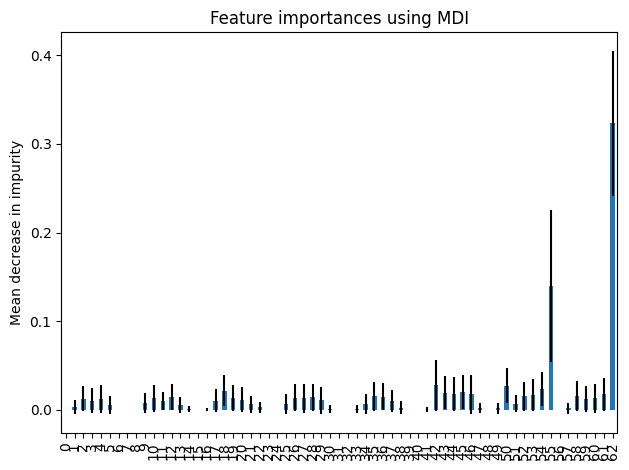

In [49]:
forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std_feat, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The first graph shows that the optimal number of Max_features for this particular problem was 20, which is far from the standard value of sqrt(d), 8 in this case. We also observe that the standard deviation increases a lot for higher values of max_features. Both observations confirms the importance of a good selection of this hyperparameter. It is important to note that the graph behaves very differently than the distributions showed during class (a fast decrease followed by a slower increase of an almost convergence).
  </p>
  <p>
    The second graph shows the importance of each feature in the dataset. We can see that many features have a importance equal to zero, those correspond to the most left and right collumns of the image, its vertical edges, that are always equal to zero, thus, do not impact the final classification. The presence of so many irrelevant features favors a ideal value of max_features higher the the usual applied value of sqrt(d).
  </p>
</div>

# **3 Measuring the importance of features**

1. Let’s consider a synthetic dataset for which the number of informative feature is controlled.
To do so, use the make_classification function from Scikit-learn to generate a dataset
with 1000 instances and 20 features among which 5 are informative and the others are not

In [29]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training:", X_train.shape[0])
print("Test:", X_test.shape[0])

Training: 800
Test: 200


2. Train a random forest classifier on the entire dataset, with 200 decision trees

In [30]:
rf = RandomForestClassifier(n_estimators=200,max_features=n)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9077090119435396


3. The resulting forest embed a feature_importances_ attribute that directly gives a feature importance measure. This is also the case of each individual tree in the forest. Using
the scikit-learn documentation, calculate the importance of each feature and rank them from the most informative to the least informative.

In [31]:
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print
print(indices)

[ 6 18  0 17  9 19 12 11  4 13 14  3 16  1 10 15  7  5  2  8]


4. Plot the feature importances in a bar plot, with the standard deviation calculated on the importances of the individual trees and comment the results.

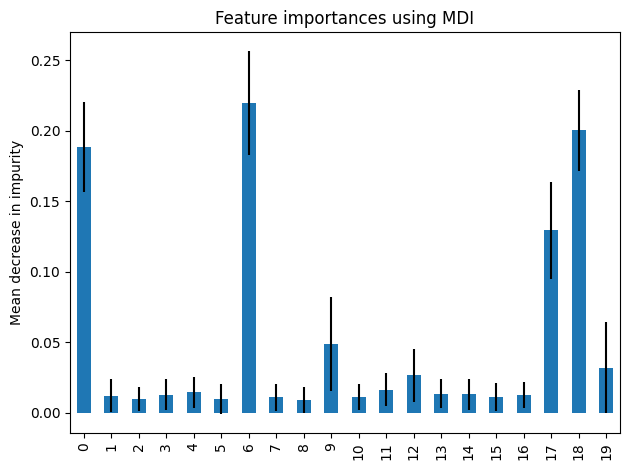

In [32]:
forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    This time, we can see a clearer plot of the feature importance. The dataset was created with 5 informative features and the graph shows a result close to what was expected. Four features are clearly more imoportant than the others, but the fifh higher (feature 9) was given a similar importance to two others.
  </p>
  <p>
    I believe this could either be caused by the data generation not following well the parameters specified or because the threes did not explored well enough those features to define their importance correctly.
  </p>
</div>

# **4 Bonus experiment : measuring similarities with Random Forest**